# Приложение Д. Эффективная настройка параметров с помощью LoRA

In [1]:
from importlib.metadata import version

pkgs = ["matplotlib",
        "numpy",
        "tiktoken",
        "torch",
        "tensorflow", # Для предобученных весов OpenAI
        "pandas"      # Загрузка наборов данных
       ]
for p in pkgs:
    print(f"{p} версия: {version(p)}")

matplotlib версия: 3.10.9
numpy версия: 2.4.6
tiktoken версия: 0.13.0
torch версия: 2.12.0
tensorflow версия: 2.21.0
pandas версия: 3.0.3


## Д.1 Введение в LoRA

- Низкоранговая адаптация (Low-rank adaptation (LoRA)) — это метод машинного обучения, который модифицирует предобученную модель для лучшего соответствия конкретному, часто меньшему набору данных путём настройки лишь небольшого низкорангового подмножества параметров модели
- Этот подход важен, поскольку он позволяет эффективно дообучать большие модели на данных, специфичных для конкретной задачи, значительно снижая вычислительные затраты и время, необходимые для тонкой настройки

- Предположим, у нас есть большая весовая матрица $W$ для заданного слоя
- Во время обратного распространения мы изучаем матрицу $\Delta W$, которая содержит информацию о том, насколько мы хотим обновить исходные веса, чтобы минимизировать функцию потерь в процессе обучения
- При обычном обучении и тонкой настройке обновление весов определяется следующим образом:

$$W_{\text{updated}} = W + \Delta W$$

- Метод LoRA, предложенный [Hu et al.](https://arxiv.org/abs/2106.09685), предлагает более эффективную альтернативу вычислению обновлений весов $\Delta W$ путём изучения его аппроксимации, $\Delta W \approx AB$
- Другими словами, в LoRA мы имеем следующее, где $A$ и $B$ — две малые весовые матрицы:

$$W_{\text{updated}} = W + AB$$

- Рисунок ниже иллюстрирует эти формулы для полной тонкой настройки и LoRA рядом друг с другом

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/appendix-e_compressed/lora-1.webp" width="800px">

- Изображения полной тонкой настройки и LoRA на рисунке выше выглядят немного иначе, чем формулы, которые были приведены ранее
- Это связано с дистрибутивным законом умножения матриц: нам не нужно складывать веса с обновлёнными весами, а можно держать их раздельно
- Например, если $x$ — это входные данные, то для обычной тонкой настройки мы можем записать следующее:

$$x (W+\Delta W) = x W + x \Delta W$$

- Аналогично, для LoRA мы можем записать следующее:

$$x (W+A B) = x W + x A B$$

- Тот факт, что мы можем держать весовые матрицы LoRA отдельно, делает LoRA особенно привлекательной
- На практике это означает, что нам вообще не нужно изменять веса предобученной модели, так как мы можем применять матрицы LoRA на лету
- После настройки набора данных и загрузки модели мы реализуем LoRA в коде, чтобы сделать эти концепции менее абстрактными

## Д.2 Подготовка набора данных

In [2]:
import requests
from pathlib import Path
import pandas as pd
from previous_chapters import (
    download_and_unzip_spam_data,
    create_balanced_dataset,
    random_split
)


url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"


try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (requests.exceptions.RequestException, TimeoutError) as e:
    print(f"Основной URL не сработал: {e}. Пробуем резервный URL...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
balanced_df = create_balanced_dataset(df)
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

Файл скачан и сохранён как sms_spam_collection\SMSSpamCollection.tsv


In [3]:
import torch
import tiktoken
from previous_chapters import SpamDataset


tokenizer = tiktoken.get_encoding("gpt2")
train_dataset = SpamDataset("train.csv", max_length=None, tokenizer=tokenizer)
val_dataset = SpamDataset("validation.csv", max_length=train_dataset.max_length, tokenizer=tokenizer)
test_dataset = SpamDataset("test.csv", max_length=train_dataset.max_length, tokenizer=tokenizer)

In [4]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

- В качестве проверочного шага мы итерируем по загрузчикам данных и проверяем, что каждый пакет содержит по 8 обучающих примеров, где каждый обучающий пример состоит из 120 токенов

In [5]:
print("Загрузчик обучающих данных:")
for input_batch, target_batch in train_loader:
    pass

print("Размеры входного пакета:", input_batch.shape)
print("Размеры пакета меток:", target_batch.shape)

Загрузчик обучающих данных:
Размеры входного пакета: torch.Size([8, 120])
Размеры пакета меток: torch.Size([8])


- Выведем общее количество пакетов в каждом наборе данных

In [6]:
print(f"{len(train_loader)} обучающих пакетов")
print(f"{len(val_loader)} валидационных пакетов")
print(f"{len(test_loader)} тестовых пакетов")

130 обучающих пакетов
19 валидационных пакетов
38 тестовых пакетов


## Д.3 Инициализация модели

In [7]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt


CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # Размер словаря
    "context_length": 1024,  # Длина контекста
    "drop_rate": 0.0,        # Коэффициент дропаута
    "qkv_bias": True         # Смещение для query-key-value
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 77.2kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 1.10MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 90.0kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [04:14<00:00, 1.96MiB/s]  
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 5.20MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 581kiB/s] 
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 676kiB/s]  


- Чтобы убедиться, что модель загружена корректно, давайте дважды проверим, генерирует ли она связный текст

In [8]:
from previous_chapters import (
    generate_text_simple,
    text_to_token_ids,
    token_ids_to_text
)


text_1 = "Every effort moves you"

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


- Затем мы подготавливаем модель к тонкой настройке для классификации, где мы заменяем выходной слой.

In [9]:
torch.manual_seed(123)

num_classes = 2
model.out_head = torch.nn.Linear(in_features=768, out_features=num_classes)

In [10]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Устройство:", device)

model.to(device);  # для классов nn.Module присваивание model = model.to(device) не требуется

Устройство: cpu


- Наконец, давайте вычислим начальную точность классификации недонастроенной модели (мы ожидаем, что она будет около 50%, что означает, что модель пока не способна надёжно различать спам- и не спам-сообщения)

In [11]:
from previous_chapters import calc_accuracy_loader

torch.manual_seed(123)
train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Точность на обучающем наборе: {train_accuracy*100:.2f}%")
print(f"Точность на валидационном наборе: {val_accuracy*100:.2f}%")
print(f"Точность на тестовом наборе: {test_accuracy*100:.2f}%")

Точность на обучающем наборе: 46.25%
Точность на валидационном наборе: 45.00%
Точность на тестовом наборе: 48.75%


## Д.4 Эффективная тонкая настройка параметров с помощью LoRA

- Мы начинаем с инициализации LoRALayer, который создаёт матрицы $A$ и $B$, а также гиперпараметр масштабирования `alpha` и гиперпараметр `rank` ($r$)
- Этот слой может принимать входные данные и вычислять соответствующий выход, как показано на рисунке ниже

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/appendix-e_compressed/lora-2.webp" width="800px">

В коде этот слой LoRA, изображённый на рисунке выше, выглядит следующим образом:

In [12]:
import math

class LoRALayer(torch.nn.Module):
    def __init__(self, in_dim, out_dim, rank, alpha):
        super().__init__()
        self.A = torch.nn.Parameter(torch.empty(in_dim, rank))
        torch.nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))  # аналогично стандартной инициализации весов
        self.B = torch.nn.Parameter(torch.zeros(rank, out_dim))
        self.alpha = alpha
        self.rank = rank

    def forward(self, x):
        x = (self.alpha / self.rank) * (x @ self.A @ self.B)
        return x

- В коде выше `rank` — это гиперпараметр, который управляет внутренней размерностью матриц $A$ и $B$
- Иными словами, этот параметр контролирует количество дополнительных параметров, вводимых LoRA, и является ключевым фактором в определении баланса между адаптивностью модели и параметрической эффективностью
- Второй гиперпараметр, `alpha`, — это масштабирующий гиперпараметр, применяемый к выходу низкоранговой адаптации
- По сути, он контролирует степень, в которой выход адаптированного слоя может влиять на исходный выход модифицируемого слоя
- Это можно рассматривать как способ регулирования влияния низкоранговой адаптации на выход слоя
- Пока что класс `LoRALayer`, который мы реализовали выше, позволяет нам преобразовывать входные данные слоя $x$
- Однако в LoRA мы обычно заинтересованы в замене существующих `Linear`-слоёв таким образом, чтобы обновление весов применялось к существующим предобученным весам, как показано на рисунке ниже

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/appendix-e_compressed/lora-3.webp" width="800px">

- Чтобы учесть веса исходного `Linear`-слоя, как показано на рисунке выше, мы реализуем слой `LinearWithLoRA` ниже, который использует ранее реализованный `LoRALayer` и может применяться для замены существующих `Linear`-слоёв в нейронной сети, например, модуля self-attention или модулей прямого распространения в LLM

In [13]:
class LinearWithLoRA(torch.nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        self.linear = linear
        self.lora = LoRALayer(
            linear.in_features, linear.out_features, rank, alpha
        )

    def forward(self, x):
        return self.linear(x) + self.lora(x)

- Поскольку мы инициализируем весовую матрицу $B$ (`self.B` в `LoRALayer`) нулевыми значениями в слое LoRA, матричное умножение $A$ и $B$ даёт матрицу, состоящую из нулей, и не влияет на исходные веса (поскольку добавление 0 к исходным весам не изменяет их)

- Чтобы опробовать LoRA на модели GPT, которую мы определили ранее, мы определяем функцию `replace_linear_with_lora` для замены всех `Linear`-слоёв в модели на новые слои `LinearWithLoRA`

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/appendix-e_compressed/lora-4.webp" width="800px">

In [ ]:
def replace_linear_with_lora(model, rank, alpha):
    for name, module in model.named_children():
        if isinstance(module, torch.nn.Linear): # isinstance — это проверка типа. Код спрашивает: "Этот модуль — полносвязный слой?"
            # Заменяем линейный слой на LinearWithLoRA
            setattr(model, name, LinearWithLoRA(module, rank, alpha)) # Динамически заменяет атрибут модели — вместо обычного линейного слоя вставляет слой с LoRA
        else:
            # Рекурсивно применяем ту же функцию к дочерним модулям
            replace_linear_with_lora(module, rank, alpha)

- Затем мы замораживаем исходные параметры модели и используем `replace_linear_with_lora` для замены указанных `Linear`-слоёв с помощью кода ниже
- Это заменит `Linear`-слои в LLM на слои `LinearWithLoRA`

In [15]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Всего обучаемых параметров до: {total_params:,}")

for param in model.parameters():
    param.requires_grad = False

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Всего обучаемых параметров после: {total_params:,}")

Всего обучаемых параметров до: 124,441,346
Всего обучаемых параметров после: 0


- Мы сократили количество обучаемых параметров почти в 50 раз при использовании LoRA
- Дважды проверим, были ли слои изменены так, как задумано, выведя архитектуру модели

In [16]:
model.to(device)

print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

- Основываясь на архитектуре модели выше, мы видим, что модель теперь содержит наши новые слои `LinearWithLoRA`
- Кроме того, поскольку мы инициализировали матрицу $B$ нулями, мы ожидаем, что начальная производительность модели останется неизменной по сравнению с предыдущей

In [17]:
torch.manual_seed(123)
train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Точность на обучающем наборе: {train_accuracy*100:.2f}%")
print(f"Точность на валидационном наборе: {val_accuracy*100:.2f}%")
print(f"Точность на тестовом наборе: {test_accuracy*100:.2f}%")

Точность на обучающем наборе: 46.25%
Точность на валидационном наборе: 45.00%
Точность на тестовом наборе: 48.75%


- Перейдём к самой интересной части и дообучим модель, повторно используя функцию обучения
- Обучение занимает около 15 минут на ноутбуке M3 MacBook Air и менее половины минуты на GPU V100 или A100

In [21]:
import time
from previous_chapters import train_classifier_simple

start_time = time.time()

torch.manual_seed(123)

# Включаем градиенты для всех параметров, так как была ошибка: ValueError: optimizer got an empty parameter list
# Оптимизатору нечего оптимизировать, поэтому код ругался
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(model.parameters(), lr=8e-4, weight_decay=0.1)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Обучение завершено за {execution_time_minutes:.2f} минут.")

Эп 1 (Шаг 000000): Потери на обучении 4.361, Потери на валидации 4.882
Эп 1 (Шаг 000050): Потери на обучении 0.162, Потери на валидации 0.153
Эп 1 (Шаг 000100): Потери на обучении 0.014, Потери на валидации 0.422
Точность на обучении: 100.00% | Точность на валидации: 92.50%
Эп 2 (Шаг 000150): Потери на обучении 0.094, Потери на валидации 0.135
Эп 2 (Шаг 000200): Потери на обучении 0.020, Потери на валидации 0.096
Эп 2 (Шаг 000250): Потери на обучении 0.133, Потери на валидации 0.250
Точность на обучении: 97.50% | Точность на валидации: 97.50%
Эп 3 (Шаг 000300): Потери на обучении 0.014, Потери на валидации 0.275
Эп 3 (Шаг 000350): Потери на обучении 0.060, Потери на валидации 0.072
Точность на обучении: 97.50% | Точность на валидации: 95.00%
Эп 4 (Шаг 000400): Потери на обучении 0.001, Потери на валидации 0.107
Эп 4 (Шаг 000450): Потери на обучении 0.041, Потери на валидации 0.071
Эп 4 (Шаг 000500): Потери на обучении 0.141, Потери на валидации 0.040
Точность на обучении: 100.00% | Точ

- Время выполнения на разных устройствах составляет:
  - 12,10 минут на MacBook M1 (CPU)
  - 2,16 минуты на MacMini M4 Pro (MPS)
  - 3,50 минуты на Jetson Nano (CUDA), по [сообщению](https://livebook.manning.com/forum?product=raschka&comment=581806) читателя
  - 1,02 минуты на DGX Spark (CUDA)

- Наконец, давайте оценим модель

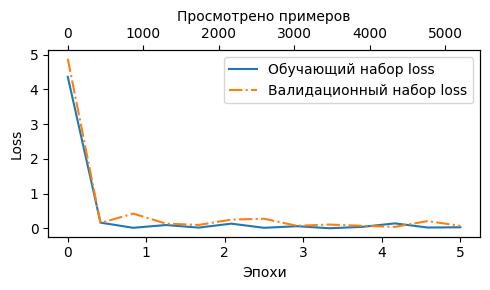

In [22]:
from previous_chapters import plot_values

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses, label="loss")

- Ранее мы вычисляли значения точности только на 5 пакетах с помощью настройки `eval_iter=5`; ниже мы вычисляем точность на полном наборе данных

In [23]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Точность на обучающем наборе: {train_accuracy*100:.2f}%")
print(f"Точность на валидационном наборе: {val_accuracy*100:.2f}%")
print(f"Точность на тестовом наборе: {test_accuracy*100:.2f}%")

Точность на обучающем наборе: 99.52%
Точность на валидационном наборе: 97.32%
Точность на тестовом наборе: 96.67%
